Author : **Kenneth Christian Nathanael**  
https://kenchristn.com | Data Analyst, Data Scientist & AI Automation Enthusiast

GitHub: https://github.com/kenchristn

# 1. Project Overview

## Objective

This project aims to evaluate whether the new landing page performs better than the old landing page in increasing user conversions.

A/B testing is a common method used in digital marketing and website optimization to compare two versions of a webpage and measure which version performs better.

In this dataset, users were randomly assigned to either the control group or the treatment group.

The goal of this analysis is to determine whether the difference in conversion rate between both groups is statistically significant and whether the company should implement the new landing page.

---

## Dataset Description

This project uses two datasets:

### ab_data.csv

Main A/B testing dataset containing:

- **user_id** → unique user identifier
- **timestamp** → visit date and time
- **group** → control or treatment
- **landing_page** → old page or new page
- **converted** → conversion result (0 = no, 1 = yes)

### countries.csv

Additional user location data containing:

- **user_id**
- **country**

Both datasets will be merged using **user_id** for further analysis.

---

## Business Problem

The company launched a new landing page and wants to understand whether it improves user conversion compared with the existing page.

The analysis focuses on answering these questions:

- Does the new landing page increase conversion rate?
- Is the difference statistically significant?
- Should the company keep the current page or launch the new version?

---

## Project Goal

This project combines:

- Data cleaning
- Exploratory data analysis
- Conversion rate analysis
- Statistical hypothesis testing
- Business recommendation

The final result will provide a data-driven recommendation based on A/B testing outcomes.

# 2. Import Libraries

## Overview

Before starting the analysis, the required Python libraries are imported.

These libraries will be used throughout the project for:

- loading and processing the datasets
- numerical calculations
- data visualization
- statistical hypothesis testing

---

## Libraries Used

### Pandas

Used for loading and manipulating structured data.

### NumPy

Used for numerical calculations and array operations.

### Matplotlib

Used to create visualizations and charts.

### Seaborn

Used for statistical data visualization.

### Statsmodels

Used to perform the two-proportion z-test for A/B testing.

---

## Purpose

Importing the required libraries at the beginning ensures that the notebook is ready for:

- data cleaning
- exploratory data analysis
- conversion rate analysis
- hypothesis testing
- visualization

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.proportion import proportions_ztest

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# 3. Data Loading and Initial Inspection

## Overview

In this step, both datasets are loaded into pandas DataFrames and reviewed.

The purpose is to verify that the files are imported correctly and to understand the dataset structure before performing data cleaning.

---

## Key Checks

The following checks will be performed:

- preview the first rows of each dataset
- review the dataset dimensions
- identify available columns
- understand the structure before cleaning

This initial inspection helps ensure the analysis starts with the correct data.

In [4]:
ab = pd.read_csv("ab_data.csv")
countries = pd.read_csv("countries.csv")

In [5]:
display(ab.head())

display(countries.head())

,user_id,timestamp,group,landing_page,converted
0,851104,11:48.6,control,old_page,0
1,804228,01:45.2,control,old_page,0
2,661590,55:06.2,treatment,new_page,0
3,853541,28:03.1,treatment,new_page,0
4,864975,52:26.2,control,old_page,1


,user_id,country
0,834778,UK
1,928468,US
2,822059,UK
3,711597,UK
4,710616,UK


In [6]:
print("AB data shape:", ab.shape)
print("Countries shape:", countries.shape)

AB data shape: (294480, 5)
Countries shape: (290586, 2)


In [7]:
print(ab.columns.tolist())

print(countries.columns.tolist())

['user_id', 'timestamp', 'group', 'landing_page', 'converted']
['user_id', 'country']


# 4. Data Cleaning

## Overview

Before performing the analysis, the dataset needs to be cleaned to ensure accurate and reliable results.

A/B testing requires clean observations because duplicate users or invalid records can affect the conversion rate and statistical testing.

This section focuses on checking data quality and preparing the final dataset for analysis.

## 4.1 Check Missing Values

The first step is checking whether there are missing values in both datasets.

Missing values can impact calculations and may lead to inaccurate analysis.

If every result is **0**, the dataset is complete.

In [8]:
print(ab.isnull().sum())

print(countries.isnull().sum())

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64
user_id    0
country    0
dtype: int64


## 4.2 Check Duplicate User IDs

Each user should only appear once in the A/B testing dataset.

Duplicate users may cause biased results because one user could be counted more than once.

This step checks how many duplicated user IDs exist.

In [9]:
ab["user_id"].duplicated().sum()

np.int64(3895)

## 4.3 Validate Group and Landing Page Mapping

The experiment should follow this structure:

- **control** → **old_page**
- **treatment** → **new_page**

Any mismatched rows should be removed because they do not match the experiment design.

In [10]:
mismatch = ab[
    ((ab["group"] == "treatment") &
     (ab["landing_page"] != "new_page")) |

    ((ab["group"] == "control") &
     (ab["landing_page"] != "old_page"))
]

mismatch.shape

(3893, 5)

## 4.4 Remove Duplicate Users and Invalid Records

The previous checks identified duplicate users and invalid group-page combinations.

To avoid indexing errors, the dataset will be cleaned in this order:

- remove duplicate user IDs
- reset the index
- recheck invalid records
- remove mismatched rows

This ensures the final dataset only contains valid experiment observations.

In [11]:
# remove duplicate users
ab = ab.drop_duplicates(subset="user_id").reset_index(drop=True)

# check mismatch again after duplicates removed
mismatch = ab[
    ((ab["group"] == "treatment") &
     (ab["landing_page"] != "new_page")) |

    ((ab["group"] == "control") &
     (ab["landing_page"] != "old_page"))
]

# remove invalid rows
ab = ab.drop(mismatch.index).reset_index(drop=True)

print("Cleaned AB data shape:", ab.shape)

Cleaned AB data shape: (288541, 5)


# 5. Exploratory Data Analysis

## Overview

After cleaning the dataset, the next step is exploring the data.

This section focuses on understanding user conversion patterns and comparing the control and treatment groups.

Exploratory analysis helps identify early insights before running statistical hypothesis testing.

The analysis will focus on:

- overall conversion rate
- conversion rate by group
- landing page distribution
- country distribution

## 5.1 Overall Conversion Rate

This step calculates the overall conversion rate across all users.

The conversion rate shows the percentage of users who completed the target action.

In [12]:
overall_conversion = ab["converted"].mean()

print("Overall conversion rate:", round(overall_conversion * 100, 2), "%")

Overall conversion rate: 11.95 %


## 5.2 Conversion Rate by Group

The conversion rate is compared between:

- **control group**
- **treatment group**

This helps identify whether the new landing page performs differently from the old page.

In [13]:
group_conversion = (
    ab.groupby("group")["converted"]
    .mean()
    .reset_index()
)

group_conversion

,group,converted
0,control,0.120290
1,treatment,0.118726


### Visualization

A bar chart is used to compare conversion rates between both groups.

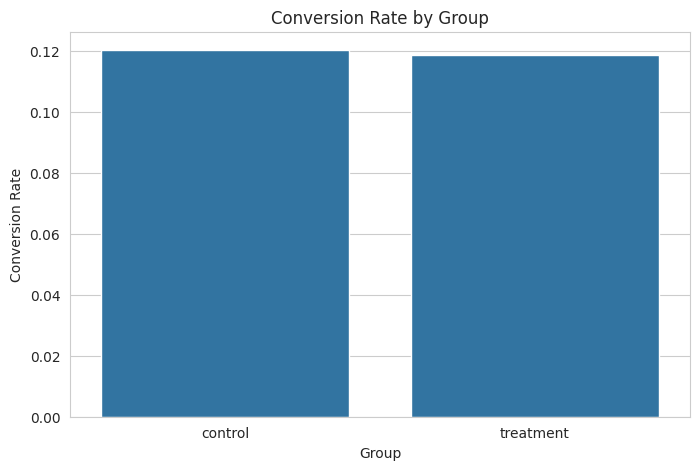

In [14]:
sns.barplot(
    data=group_conversion,
    x="group",
    y="converted"
)

plt.title("Conversion Rate by Group")
plt.ylabel("Conversion Rate")
plt.xlabel("Group")
plt.show()

## 5.3 Landing Page Distribution

This step checks how users are distributed across both landing pages.

A balanced distribution helps confirm that the experiment was assigned correctly.

In [15]:
ab["landing_page"].value_counts()

,count
landing_page,
new_page,144315
old_page,144226


### Visualization

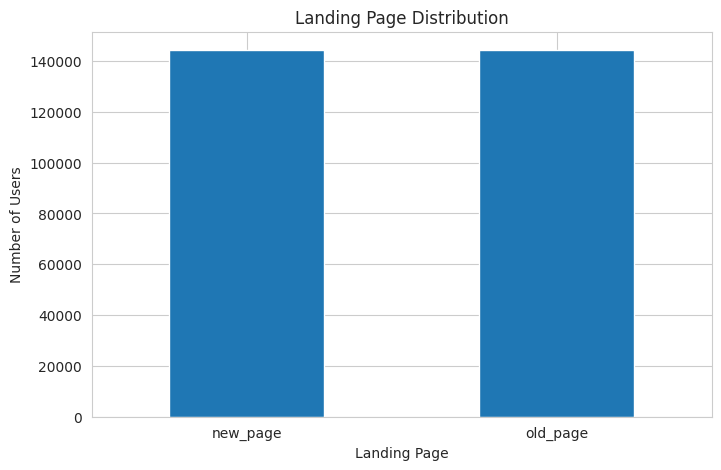

In [20]:
page_counts = ab["landing_page"].value_counts()

page_counts.plot(
    kind="bar"
)

plt.title("Landing Page Distribution")
plt.xlabel("Landing Page")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)

plt.show()

## 5.4 Country Distribution

The country dataset will be merged with the A/B testing dataset.

This allows analysis by user location.

In [16]:
df = ab.merge(countries, on="user_id", how="left")

df["country"].value_counts()

,count
country,
US,202187
UK,71961
CA,14394


### Visualization

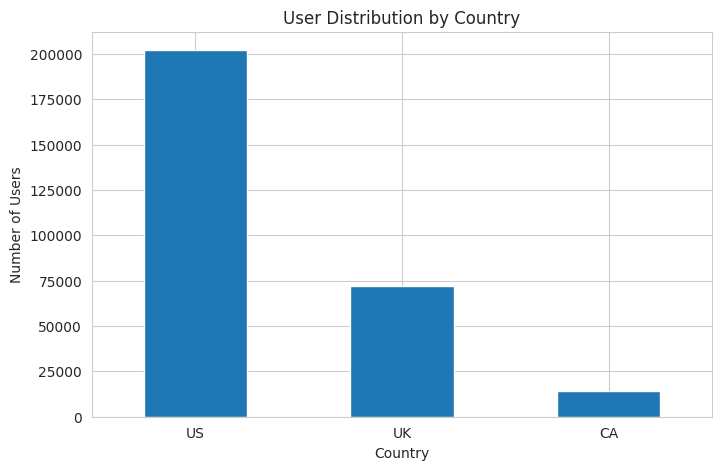

In [21]:
country_counts = (
    df["country"]
    .value_counts()
)

country_counts.plot(
    kind="bar"
)

plt.title("User Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)

plt.show()

# 6. Hypothesis Testing

## Overview

After exploring the dataset, the next step is statistical hypothesis testing.

The goal is to determine whether the difference in conversion rate between the control group and the treatment group is statistically significant.

A two-proportion z-test is used because:

- there are two groups
- the outcome is binary (converted or not converted)
- the dataset is large

---

## Hypotheses

### Null Hypothesis (H₀)

There is no significant difference in conversion rate between the control group and the treatment group.

### Alternative Hypothesis (H₁)

There is a significant difference in conversion rate between the two groups.

---

## Significance Level

The significance level used in this analysis is:

**α = 0.05**

Decision rule:

- **p-value < 0.05** → reject H₀
- **p-value ≥ 0.05** → fail to reject H₀

---

## Why Use a Two-Proportion Z-Test?

A two-proportion z-test is used because this analysis compares conversion rates between two independent groups:

- **control**
- **treatment**

The target variable (**converted**) is binary:

- **1 = converted**
- **0 = not converted**

This makes the analysis focused on comparing proportions.

A t-test is generally used for continuous numerical values, while a chi-square test measures relationships between categories.

Because this project compares two conversion proportions with a large sample size, the two-proportion z-test is the most appropriate method.

## 6.1 Prepare Data for Testing

This step calculates:

- total conversions
- total users

for both control and treatment groups.

In [17]:
control = ab[ab["group"] == "control"]
treatment = ab[ab["group"] == "treatment"]

success = np.array([
    control["converted"].sum(),
    treatment["converted"].sum()
])

nobs = np.array([
    control.shape[0],
    treatment.shape[0]
])

print("Conversions:", success)
print("Users:", nobs)

Conversions: [17349 17134]
Users: [144226 144315]


## 6.2 Run Two-Proportion Z-Test

The z-test is used to compare conversion rates between both groups.

In [18]:
z_stat, p_value = proportions_ztest(
    success,
    nobs
)

print("Z-statistic:", round(z_stat, 4))
print("P-value:", round(p_value, 4))

Z-statistic: 1.2949
P-value: 0.1953


## 6.3 Interpretation

Based on the p-value, the result can be interpreted using the significance level.

In [19]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference between both groups.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference between both groups.")

Fail to reject the null hypothesis.
There is no statistically significant difference between both groups.


# 7. Conclusion and Business Recommendation

## Summary of Findings

This analysis evaluated whether the new landing page performed better than the existing landing page using A/B testing.

The dataset was cleaned by removing duplicate users and invalid group-page combinations before analysis.

The final cleaned dataset contained **288,541 valid observations**.

Key findings:

- Overall conversion rate: **11.95%**
- Control group conversion rate: **12.03%**
- Treatment group conversion rate: **11.87%**
- Z-statistic: **1.2949**
- P-value: **0.1953**

---

## Interpretation

The treatment group showed a slightly lower conversion rate than the control group.

However, the difference between both groups was very small.

The p-value was greater than the significance level of **0.05**, which means the difference was **not statistically significant**.

Based on the hypothesis test, the null hypothesis cannot be rejected.

This indicates there is not enough evidence to conclude that the new landing page performs differently from the old landing page.

---

## Business Recommendation

Based on the analysis:

- the current landing page should remain active
- the new landing page should not be fully implemented yet
- additional A/B testing may be needed before making a final rollout decision

Possible next steps:

- test a different landing page design
- analyze performance by country
- analyze conversion by time or user segment
- run another experiment with updated variations

The current results suggest that the new landing page does not provide a statistically significant improvement in conversion performance.